In [1]:
!pip install -U sentence-transformers seaborn matplotlib
!pip install nbstripout

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

In [2]:
sentences = [
    # Topic 1: Cricket
    "The batsman hit a magnificent six over the long-on boundary.",
    "Fielders were placed strategically to stop the captain from scoring runs.",
    "The pitch seems to favor spinners in the second innings of the match.",

    # Topic 2: Cooking
    "Whisk the eggs and sugar together until the mixture is light and fluffy.",
    "Slow-cooking the meat ensures it remains tender and full of flavor.",
    "Add a pinch of sea salt and fresh herbs to enhance the aroma of the sauce.",
    "Preheat the oven to 180°C before placing the baking tray inside.",

    # Topic 3: Cybersecurity
    "Multi-factor authentication adds an essential layer of security to accounts.",
    "Encryption algorithms are used to protect sensitive data from unauthorized access.",
    "A firewall monitors incoming and outgoing network traffic to block threats."
]

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate Embeddings
embeddings = model.encode(sentences, convert_to_tensor=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

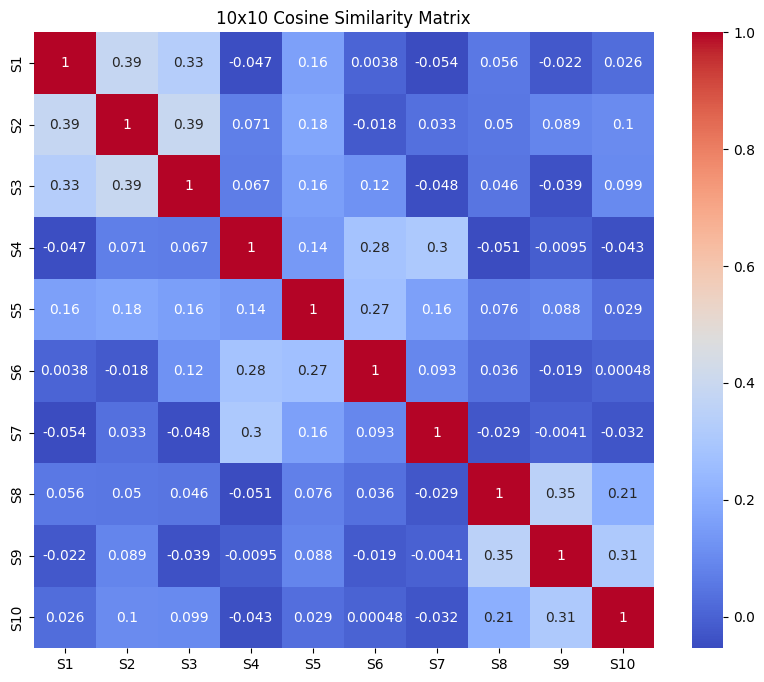

In [3]:
# Compute Cosine Similarity
cosine_scores = util.cos_sim(embeddings, embeddings).cpu().numpy()

# Display 10x10 Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores, annot=True, cmap='coolwarm',
            xticklabels=[f"S{i}" for i in range(1, 11)],
            yticklabels=[f"S{i}" for i in range(1, 11)])
plt.title("10x10 Cosine Similarity Matrix")
plt.show()

In [4]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity between query and all sentences
query_scores = util.cos_sim(query_embedding, embeddings)[0]

# Find top 2 indices
top_results = np.argsort(query_scores.cpu().numpy())[::-1][:2]

print(f"Query: {query}\n" + "-"*40)
for idx in top_results:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {query_scores[idx]:.4f}\n")

Query: The bowler took three wickets in one over
----------------------------------------
Sentence: The batsman hit a magnificent six over the long-on boundary.
Similarity Score: 0.5387

Sentence: The pitch seems to favor spinners in the second innings of the match.
Similarity Score: 0.4058

